# Introduction to Quantum Toolbox in Julia (QuantumToolbox.jl)

Lecturer: **Yi-Te Huang**

---

## Table of Content

- QuTiP organization
- `QuantumToolbox.jl`
- `QuantumObject` (`Qobj`)
  - States
  - Operators
- Composite systems
  - Tensor product
  - Partial trace
  - Multisite operator
- `QuantumObjectEvolution` (`QobjEvo`)
  - Generate `QobjEvo`
  - Using parameters `p`

## QuTiP organization

[QuTiP](https://qutip.org/) provides an open-source framework for simulating the dynamics of open and closed quantum systems, widely used in quantum optics, quantum information, and condensed matter physics.

The [QuTiP GitHub organization](https://github.com/qutip) now hosts not only the original `Python` packages:

- [`qutip`](https://github.com/qutip/qutip): the core package — Quantum Toolbox in Python — providing `Qobj`, solvers for the Schrödinger and master equations, and the broader simulation toolkit.
- [`qutip-qip`](https://github.com/qutip/qutip-qip): a package for quantum information processing, providing basic tools for quantum computing simulation, both for simple quantum algorithm design and for experimental realization.
- [`qutip-qoc`](https://github.com/qutip/qutip-qoc): a package for quantum optimal control, providing tools to numerically find pulses that steer a quantum system toward a desired gate or state.

but also the `Julia` packages:

- [`QuantumToolbox.jl`](https://github.com/qutip/QuantumToolbox.jl): a cutting-edge `Julia` package designed for quantum physics simulations. It combines the simplicity and power of `Julia` with advanced features like GPU acceleration and distributed computing, making simulation of quantum systems more accessible and efficient.
- [`HierarchicalEOM.jl`](https://github.com/qutip/HierarchicalEOM.jl): a specialized package implementing the **H**ierarchical **E**quations **O**f **M**otion (HEOM) method, for strongly-coupled system-bath dynamics beyond what Lindblad master equations can capture.

If you are already using QuTiP in your personal projects or research. The admin team would love to hear from you! Take our 2026 User Survey : https://forms.gle/mXAzrKYFBFJMm4fC9 (~5 minutes).

## `QuantumToolbox.jl`

The figure below gives an overview of `QuantumToolbox.jl`.

<img src="https://quantum-journal.org/wp-content/uploads/2025/09/QuantumToolbox.jl_.png" width="1000">

This package provides many features including time-evolution and steady-state solvers, correlation functions, visualizations, GPU acceleration, distributed computing, automatic differentiation, and more. See our documentation (https://qutip.org/QuantumToolbox.jl/stable/) for the full user guide and API reference.

To install `QuantumToolbox.jl`, run the following commands inside Julia's session:

```julia
using Pkg
Pkg.add("QuantumToolbox")
```

Before anything else, it's good practice to check your `QuantumToolbox` version and system information through either:

- `QuantumToolbox.about()`
- `QuantumToolbox.versioninfo()`

In [1]:
using QuantumToolbox
using LinearAlgebra, CairoMakie

QuantumToolbox.about()


 QuantumToolbox.jl: Quantum Toolbox in Julia
≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡≡
Copyright © QuTiP team 2022 and later.
Current admin team:
    Alberto Mercurio and Yi-Te Huang

Package information:
Julia              Ver. 1.12.7
QuantumToolbox     Ver. 0.47.2
SciMLOperators     Ver. 1.29.0
LinearSolve        Ver. 3.87.0
OrdinaryDiffEqCore Ver. 4.14.1

System information:
OS       : Linux (x86_64-linux-gnu)
CPU      : 4 × AMD EPYC 7763 64-Core Processor
Memory   : 15.621 GB
WORD_SIZE: 64
LIBM     : libopenlibm
LLVM     : libLLVM-18.1.7 (ORCJIT, znver3)
BLAS     : libopenblas64_.so (ilp64)
Threads  : 4 (on 4 virtual cores)

+---------------------------------------------------+
| Please cite QuantumToolbox.jl in your publication |
+---------------------------------------------------+
For your convenience, a bibtex reference can be easily generated using `QuantumToolbox.cite()`.



## `QuantumObject` (`Qobj`)

The fundamental data structure of QuantumToolbox.jl is `QuantumObject` (or alias: `Qobj`). It represents quantum states, operators, and superoperators in a single and unified type, just like `Qobj` in `qutip`.

Because `QuantumToolbox.jl` mirrors `qutip`'s API and data model, most of what you learn about `Qobj` carries over almost one-to-one to Julia's `QuantumObject` (or `Qobj`).

The definition of the `QuantumObject` (`Qobj`) structure is:

```julia
struct QuantumObject{Ttype <: QuantumObjectType, Tdims <: Dimensions, Tdata <: AbstractArray}
    data::Tdata
    type::Ttype
    dimensions::Tdims
end
```

which includes three fields:

- `data`: the underlying array (dense or sparse) holding the numerical values
- `type`: what kind of quantum object it is, e.g., `Ket`, `Bra`, `Operator`, or `SuperOperator`.
- `dimensions` (`dims`): the dimensions of the underlying Hilbert space(s), used for tracking tensor-product structure.

In [2]:
ψ = Qobj(ComplexF64[1, 0, 0])
ψ


Quantum Object:   type=Ket()   dims=([3], [1])   size=(3,)
3-element Vector{ComplexF64}:
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [3]:
@show ψ.type
@show ψ.dimensions
@show ψ.dims;

ψ.type = Ket()
ψ.dimensions = Dimensions(Space(3), Space(1))
ψ.dims = ([3], [1])


Because `type` and `dims` are tracked automatically, QuantumToolbox.jl knows how to correctly apply operations like the adjoint (`'`), multiplication, or tensor products (`⊗`) without you having to manually manage array shapes.

`QuantumToolbox.jl` also provides the similar boolean functions that `qutip` has, in order to check the type of a `Qobj`:

In [4]:
@show isket(ψ)
@show isbra(ψ)
@show isoper(ψ);

isket(ψ) = true
isbra(ψ) = false
isoper(ψ) = false


The rules for mathematical operations on `Qobj` are similar to the standard scalar, vector, and matrix arithmetic.

Furthermore, `QuantumToolbox.jl` supports most of the basic functions provided in `LinearAlgebra.jl` (see documentation for the full list of supported `LinearAlgebra` functions: https://qutip.org/QuantumToolbox.jl/stable/users_guide/QuantumObject/QuantumObject_functions).

In [5]:
ψ' # adjoint (conjugate transpose) of ψ


Quantum Object:   type=Bra()   dims=([1], [3])   size=(1, 3)
1×3 adjoint(::Vector{ComplexF64}) with eltype ComplexF64:
 1.0-0.0im  0.0-0.0im  0.0-0.0im

In [6]:
@show ψ' * ψ
@show dot(ψ, ψ)
@show norm(ψ);

ψ' * ψ = 1.0 + 0.0im
dot(ψ, ψ) = 1.0 + 0.0im
norm(ψ) = 1.0


### States

See documentation for the full list of state generating functions: https://qutip.org/QuantumToolbox.jl/stable/users_guide/QuantumObject/QuantumObject#States

Common constructors for **kets** (pure states):

- `basis(N, n)` / `fock(N, n)`: Fock (number) state $|n\rangle$ with Fock space cutoff `N`
- `coherent(N, α)`: coherent state $|\alpha\rangle$ with Fock space cutoff `N`

In [7]:
N = 6
ψ2 = basis(N, 2)


Quantum Object:   type=Ket()   dims=([6], [1])   size=(6,)
6-element Vector{ComplexF64}:
 0.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

In [8]:
α = 0.6 + 0.8im
ψα = coherent(N, α)


Quantum Object:   type=Ket()   dims=([6], [1])   size=(6,)
6-element Vector{ComplexF64}:
    0.6065294726093426 + 0.0im
   0.36392660704753377 + 0.48523547606337836im
  -0.12005840288399723 + 0.41162880988799033im
  -0.23229369315525467 + 0.08735831195582226im
  -0.10236225475170387 - 0.06526322124586813im
 -0.004823152878136036 - 0.06341326737667487im

To create a superposition state:

In [9]:
ψ_sup = basis(N, 0) + basis(N, 2)


Quantum Object:   type=Ket()   dims=([6], [1])   size=(6,)
6-element Vector{ComplexF64}:
 1.0 + 0.0im
 0.0 + 0.0im
 1.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im
 0.0 + 0.0im

Noticed that this state is not normalized, we can use `normalize!` (mutating version):

In [10]:
normalize!(ψ_sup)
ψ_sup


Quantum Object:   type=Ket()   dims=([6], [1])   size=(6,)
6-element Vector{ComplexF64}:
 0.7071067811865475 + 0.0im
                0.0 + 0.0im
 0.7071067811865475 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im

Common constructors for **density matrices** (mixed states):

- `ket2dm(ψ)`: convert an existing ket $|\psi\rangle$ into a density matrix $|\psi\rangle\langle\psi|$
- `fock_dm(N, n)` / `coherent_dm(N, α)`: directly build $|\psi\rangle\langle\psi|$
- `thermal_dm(N, n_th)`: thermal state with mean occupation `n_th`

In [11]:
ket2dm(ψ2)


Quantum Object:   type=Operator()   dims=([6], [6])   size=(6, 6)   ishermitian=true
6×6 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im

In [12]:
fock_dm(N, 0)


Quantum Object:   type=Operator()   dims=([6], [6])   size=(6, 6)   ishermitian=true
6×6 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im

In [13]:
n_th = 0.5
ρ_th = thermal_dm(N, n_th)  # thermal state


Quantum Object:   type=Operator()   dims=([6], [6])   size=(6, 6)   ishermitian=true
6×6 Matrix{Float64}:
 0.667582  0.0       0.0        0.0        0.0         0.0
 0.0       0.222527  0.0        0.0        0.0         0.0
 0.0       0.0       0.0741758  0.0        0.0         0.0
 0.0       0.0       0.0        0.0247253  0.0         0.0
 0.0       0.0       0.0        0.0        0.00824176  0.0
 0.0       0.0       0.0        0.0        0.0         0.00274725

### Operators

See documentation for the full list of operator generating functions: https://qutip.org/QuantumToolbox.jl/stable/users_guide/QuantumObject/QuantumObject#Operators

Common constructors for operator:

- `qeye(N)`: identity operator with size `N`
- `destroy(N)`, `create(N)`: bosonic ladder operators $a$, $a^\dagger$ with Fock space cutoff `N`
- `sigmax()`, `sigmay()`, `sigmaz()`, `sigmap()`, `sigmam()`: Pauli operators ($\sigma_x$, $\sigma_y$, $\sigma_z$)and qubit raising-lowering operators ($\sigma_+$, $\sigma_-$)

In [14]:
a = destroy(N)
N_op = a' * a  # number operator


Quantum Object:   type=Operator()   dims=([6], [6])   size=(6, 6)   ishermitian=true
6×6 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 5 stored entries:
     ⋅          ⋅          ⋅          ⋅          ⋅          ⋅    
     ⋅      1.0+0.0im      ⋅          ⋅          ⋅          ⋅    
     ⋅          ⋅      2.0+0.0im      ⋅          ⋅          ⋅    
     ⋅          ⋅          ⋅      3.0+0.0im      ⋅          ⋅    
     ⋅          ⋅          ⋅          ⋅      4.0+0.0im      ⋅    
     ⋅          ⋅          ⋅          ⋅          ⋅      5.0+0.0im

The most important information about quantum systems comes from calculating the expectation value of operators as the state or density matrix of the system varies in time, i.e, $\mathrm{Tr}[\hat{O}\rho]$.

Therefore, we demonstrate the use of the `expect` function:

```julia
expect(op, state)
```

- `op`: can be specified as a single or a list of `Operator`.
- `state`: can be specified as a single or a list of `Qobj`.

For example, here we consider the expectation value of number operator $a^\dagger a$ for the following states:

- `basis(N, 2)`: theoretical value is $2.0$
- `coherent(N, α)`: theoretical value is $|\alpha|^2=|0.6+0.8i|^2 = 1.0$
- `thermal_dm(N, n_th)`: theoretical value is $n_\mathrm{th}=0.5$

In [15]:
expect(N_op, [ψ2, ψα, ρ_th])

3-element Vector{ComplexF64}:
  2.0000000000000004 + 0.0im
  0.9995479440520547 - 1.4094628242311558e-17im
 0.49175824175824173 + 0.0im

The results are slightly different from the theoretical values due to the finite truncation of the Hilbert (Fock) space `N`. We can increase the truncation to get more accurate results:

In [16]:
N = 10
expect(num(N), [basis(N, 2), coherent(N, α), thermal_dm(N, n_th)])

3-element Vector{ComplexF64}:
               2.0 + 0.0im
 0.999999925936511 + 6.939740936854483e-18im
 0.499830646253895 + 0.0im

`QuantumToolbox` also provides visualization functions built on top of `Makie`, so you can inspect a state without manually writing plotting code.

`plot_fock_distribution` shows the (occupation) probability of finding a given quantum state in each Fock (photon-number) state — a quick way to visually compare different types of states.

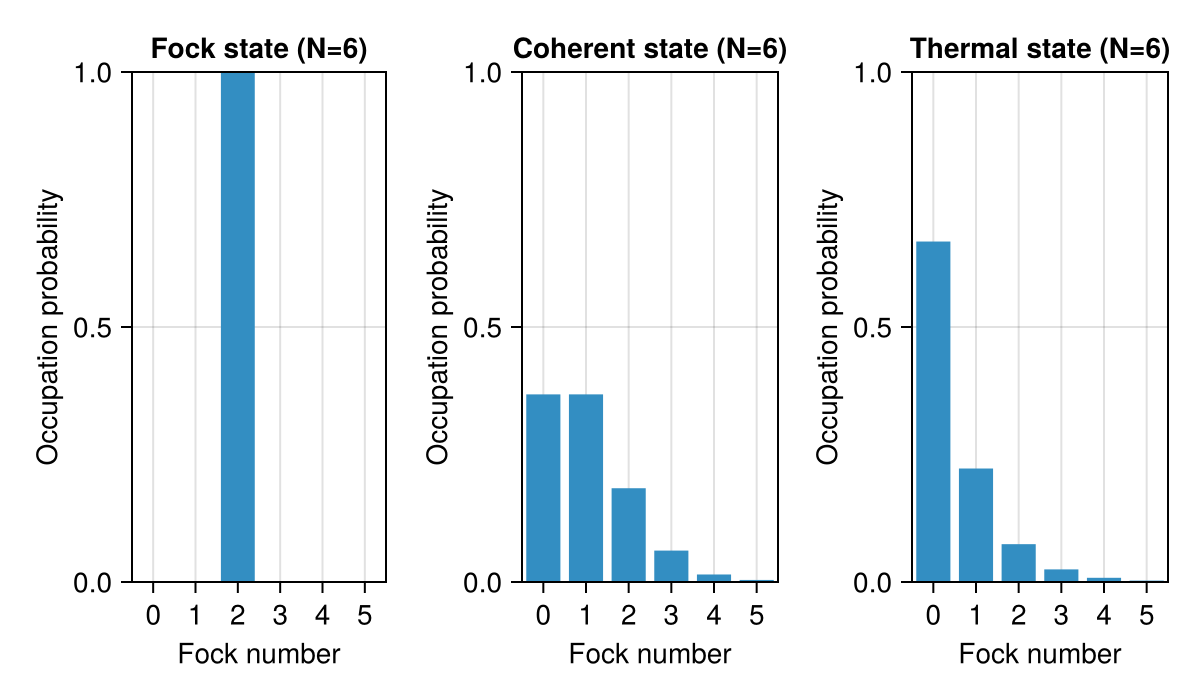

In [17]:
fig = Figure(size = (600, 350))

_, ax1, _ = plot_fock_distribution(ψ2; location=fig[1,1])
ax1.title = "Fock state (N=6)"

_, ax2, _ = plot_fock_distribution(ψα; location=fig[1,2])
ax2.title = "Coherent state (N=6)"

_, ax3, _ = plot_fock_distribution(ρ_th; location=fig[1,3])
ax3.title = "Thermal state (N=6)"

fig

## Composite systems

### Tensor product

Multi-partite Hilbert spaces are built with `kron(...)` or `tensor(...)` or `⊗`. The resulting `Qobj.dimensions` (or `Qobj.dims`) records the tensor structure, which is what that allow us do partial trace (`ptrace`) later.

In [18]:
# two qubits: operators acting on qubit 1 or qubit 2 within the joint 2x2 space
sx1 = tensor(sigmax(), qeye(2))
sx2 = tensor(qeye(2), sigmax())

@show sx1.dimensions
@show sx2.dimensions
@show sx1.dims
@show sx2.dims;

sx1.dimensions = Dimensions(TensorSpace(Space(2), Space(2)), TensorSpace(Space(2), Space(2)))
sx2.dimensions = Dimensions(TensorSpace(Space(2), Space(2)), TensorSpace(Space(2), Space(2)))
sx1.dims = ([2, 2], [2, 2])
sx2.dims = ([2, 2], [2, 2])


### Partial trace

The partial trace is an operation that reduces the dimension of a Hilbert space by eliminating some degrees of freedom by averaging (tracing). In this sense it is therefore the converse of the tensor product. It is useful when one is interested in only a part of a coupled quantum system.

For open quantum systems, this typically involves tracing over the environment leaving only the system of interest.

In `QuantumToolbox`, the function `ptrace` is used to take partial traces. `ptrace` takes one `QuantumObject{Operator}` as an input, and also one argument `sel`, which marks the component systems that should be kept, and all the other components are traced out. The type of `sel` can be either `Integer`, `Tuple`, or `Vector`.

For example, we consider a Bell state:

```math
|\Phi^+\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle+|11\rangle\right)
```

In [19]:
# Bell state (|00> + |11>) / sqrt(2)
ψ_bell = normalize!(
    tensor(basis(2, 0), basis(2, 0)) + tensor(basis(2, 1), basis(2, 1))
)
ρ_bell = ket2dm(ψ_bell)


Quantum Object:   type=Operator()   dims=([2, 2], [2, 2])   size=(4, 4)   ishermitian=true
4×4 Matrix{ComplexF64}:
 0.5+0.0im  0.0+0.0im  0.0+0.0im  0.5+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.5+0.0im  0.0+0.0im  0.0+0.0im  0.5+0.0im

In [20]:
ptrace(ρ_bell, 1) # keep qubit 1 and trace out qubit 2


Quantum Object:   type=Operator()   dims=([2], [2])   size=(2, 2)   ishermitian=true
2×2 Matrix{ComplexF64}:
 0.5+0.0im  0.0+0.0im
 0.0+0.0im  0.5+0.0im

Another example with three qubits:

In [21]:
ψ3 = tensor(
    basis(2, 0),
    basis(2, 1),
    normalize(basis(2, 0) + basis(2, 1))
)


Quantum Object:   type=Ket()   dims=([2, 2, 2], [1])   size=(8,)
8-element Vector{ComplexF64}:
                0.0 + 0.0im
                0.0 + 0.0im
 0.7071067811865475 + 0.0im
 0.7071067811865475 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im
                0.0 + 0.0im

In [22]:
ptrace(ψ3, 1) # keep qubit 1, and trace out 2nd and 3rd qubits


Quantum Object:   type=Operator()   dims=([2], [2])   size=(2, 2)   ishermitian=true
2×2 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im
 0.0-0.0im  0.0+0.0im

In [23]:
ptrace(ψ3, (1, 3)) # keep 1st and 3rd qubits, and trace out qubit 2


Quantum Object:   type=Operator()   dims=([2, 2], [2, 2])   size=(4, 4)   ishermitian=true
4×4 Matrix{ComplexF64}:
 0.5+0.0im  0.5+0.0im  0.0+0.0im  0.0+0.0im
 0.5-0.0im  0.5+0.0im  0.0+0.0im  0.0+0.0im
 0.0-0.0im  0.0-0.0im  0.0+0.0im  0.0+0.0im
 0.0-0.0im  0.0-0.0im  0.0-0.0im  0.0+0.0im

### Multisite operator

For many-body systems, the helper function `multisite_operator` is often more convenient than assembling the full tensor product of many `Operator` by hand. It builds an `Operator` on the full Hilbert space from a few `Pair`s (`site-index => Operator`) and handles the untouched sites implicitly as identities. 

Note that this function is efficient because it does not construct explicit identity operators for the remaining sites, which avoids extra memory allocation and keeps the operator assembly lightweight. Therefore, `multisite_operator` is especially useful when you want an `Operator` acting on a few selected sites, or an interaction term that is nontrivial only on selected sites, particularly in spin chains and other composite systems with a fixed site ordering.

For example, we consider three coupled qubits, the Hamiltonian describing this system is:

```math
H = \sigma_z^{(1)} + \sigma_z^{(2)} + \sigma_z^{(3)} + 0.5\;\sigma_x^{(1)} \otimes \sigma_x^{(2)} + 0.25\;\sigma_x^{(2)} \otimes \sigma_x^{(3)}
```

In [24]:
H = tensor(sigmaz(), qeye(2), qeye(2)) +
    tensor(qeye(2), sigmaz(), qeye(2)) +
    tensor(qeye(2), qeye(2), sigmaz()) +
    0.5  * tensor(sigmax(), sigmax(), qeye(2)) +
    0.25 * tensor(qeye(2), sigmax(), sigmax())


Quantum Object:   type=Operator()   dims=([2, 2, 2], [2, 2, 2])   size=(8, 8)   ishermitian=true
8×8 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 24 stored entries:
  3.0+0.0im       ⋅           ⋅      …       ⋅       0.5+0.0im       ⋅    
      ⋅       1.0+0.0im  0.25+0.0im          ⋅           ⋅       0.5+0.0im
      ⋅      0.25+0.0im   1.0+0.0im          ⋅           ⋅           ⋅    
 0.25+0.0im       ⋅           ⋅          0.5+0.0im       ⋅           ⋅    
      ⋅           ⋅       0.5+0.0im          ⋅           ⋅      0.25+0.0im
      ⋅           ⋅           ⋅      …  -1.0+0.0im  0.25+0.0im       ⋅    
  0.5+0.0im       ⋅           ⋅         0.25+0.0im  -1.0+0.0im       ⋅    
      ⋅       0.5+0.0im       ⋅              ⋅           ⋅      -3.0+0.0im

We can also construct this Hamiltonian using `multisite_operator`:

In [25]:
dims = (2, 2, 2)
H = multisite_operator(dims, 1 => sigmaz()) +
    multisite_operator(dims, 2 => sigmaz()) +
    multisite_operator(dims, 3 => sigmaz()) +
    0.5  * multisite_operator(dims, 1 => sigmax(), 2 => sigmax()) +
    0.25 * multisite_operator(dims, 2 => sigmax(), 3 => sigmax())


Quantum Object:   type=Operator()   dims=([2, 2, 2], [2, 2, 2])   size=(8, 8)   ishermitian=true
8×8 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 24 stored entries:
  3.0+0.0im       ⋅           ⋅      …       ⋅       0.5+0.0im       ⋅    
      ⋅       1.0+0.0im  0.25+0.0im          ⋅           ⋅       0.5+0.0im
      ⋅      0.25+0.0im   1.0+0.0im          ⋅           ⋅           ⋅    
 0.25+0.0im       ⋅           ⋅          0.5+0.0im       ⋅           ⋅    
      ⋅           ⋅       0.5+0.0im          ⋅           ⋅      0.25+0.0im
      ⋅           ⋅           ⋅      …  -1.0+0.0im  0.25+0.0im       ⋅    
  0.5+0.0im       ⋅           ⋅         0.25+0.0im  -1.0+0.0im       ⋅    
      ⋅       0.5+0.0im       ⋅              ⋅           ⋅      -3.0+0.0im

Since the Hilbert space dimension of all sites are equal in this case, we can just specify the number of sites `N` to `multisite_operator`, namely

In [26]:
N = Val(3)
H = multisite_operator(N, 1 => sigmaz()) +
    multisite_operator(N, 2 => sigmaz()) +
    multisite_operator(N, 3 => sigmaz()) +
    0.5  * multisite_operator(N, 1 => sigmax(), 2 => sigmax()) +
    0.25 * multisite_operator(N, 2 => sigmax(), 3 => sigmax())


Quantum Object:   type=Operator()   dims=([2, 2, 2], [2, 2, 2])   size=(8, 8)   ishermitian=true
8×8 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 24 stored entries:
  3.0+0.0im       ⋅           ⋅      …       ⋅       0.5+0.0im       ⋅    
      ⋅       1.0+0.0im  0.25+0.0im          ⋅           ⋅       0.5+0.0im
      ⋅      0.25+0.0im   1.0+0.0im          ⋅           ⋅           ⋅    
 0.25+0.0im       ⋅           ⋅          0.5+0.0im       ⋅           ⋅    
      ⋅           ⋅       0.5+0.0im          ⋅           ⋅      0.25+0.0im
      ⋅           ⋅           ⋅      …  -1.0+0.0im  0.25+0.0im       ⋅    
  0.5+0.0im       ⋅           ⋅         0.25+0.0im  -1.0+0.0im       ⋅    
      ⋅       0.5+0.0im       ⋅              ⋅           ⋅      -3.0+0.0im

## `QuantumObjectEvolution` (`QobjEvo`)

### Generate `QobjEvo`

So far, every operator we've built has been *time-independent*. But many physical setups (e.g., a driven qubit, a pulsed laser, or a time-varying decay rate) need a Hamiltonian (or collapse operator) that are *time-dependent*. `QuantumToolbox.jl` represents such objects with `QuantumObjectEvolution` (or its alias `QobjEvo`), and its data field takes advantage of [`SciMLOperators.jl`](https://docs.sciml.ai/SciMLOperators/stable/).

The basic construction of a `QobjEvo` is built from a time-independent `Qobj` together with a coefficient function of the form `f(p, t)`:

```math
\hat{H}(t) = f(t)\hat{H}_0
```


In [27]:
f(p, t) = sin(t)

H_t = QobjEvo(sigmax(), f)


Quantum Object Evo.:   type=Operator()   dims=([2], [2])   size=(2, 2)   ishermitian=true   isconstant=false
ScalarOperator(0.0 + 0.0im) * MatrixOperator(2 × 2)

Note that even if you don't use `p`, the function signature still needs it as the first argument. We'll see what `p` is later.

In general, we will look at a case with the total Hamiltonian can be separate into time-independent part ($\hat{H}_0$) and a summation of many time-dependent operators, which takes the form:

```math
\hat{H}(t) = \hat{H}_0 + \sum_j f_j(t)\hat{H}_j
```

The following code sets up this problem by using a `Tuple` which contains many time-dependent pairs `(H_j, f_j)`, where
- `H_j` is a `Qobj`
- `f_j` is a coefficient function of the form `f_j(p, t)`.

In [28]:
H0 = qeye(2) # time-independent

H1 = sigmax()
f1(p, t) = sin(t)

H2 = sigmay()
f2(p, t) = cos(t)

H_t = QobjEvo((H0, (H1, f1), (H2, f2)))


Quantum Object Evo.:   type=Operator()   dims=([2], [2])   size=(2, 2)   ishermitian=true   isconstant=false
(DiagonalOperator(2 × 2) + ScalarOperator(0.0 + 0.0im) * MatrixOperator(2 × 2) + ScalarOperator(0.0 + 0.0im) * MatrixOperator(2 × 2))

This is equivalent to building each term separately and adding them with `+`:

```julia
H0 + QobjEvo(H1, f1) + QobjEvo(H2, f2)
```

A `QobjEvo` can be **called** like a function of time, returning the instantaneous `Qobj` at that time:

In [29]:
coef(p, t) = sin(π * t)
Ht = QobjEvo(sigmaz(), coef)

Ht(0.25)  # the Qobj at t = 0.25


Quantum Object:   type=Operator()   dims=([2], [2])   size=(2, 2)   ishermitian=true
2×2 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 2 stored entries:
 0.707107+0.0im            ⋅    
          ⋅      -0.707107+0.0im

Just like `Qobj`, it also exposes `type` and `dims`:

In [30]:
@show Ht.type
@show Ht.dims
@show isconstant(Ht); # false — confirms this is time-dependent

Ht.type = Operator()
Ht.dims = ([2], [2])
isconstant(Ht) = false


### Using parameter `p`

So far, the coefficient functions have only depended on time `t`, with any physical constants hardcoded directly into the function body. This is inconvenient if you want to re-run the same problem with different parameter values without redefining the function each time.

The `p` argument exists for exactly this: it allows you to pass parameters into the coefficient function, rather than hardcoding them.

`p` can be a `Vector`:

In [31]:
f1_v(p, t) = p[1] * cos(p[2] * t)
f2_v(p, t) = p[3] * sin(p[4] * t)

H_t_v = sigmaz() + QobjEvo(sigmax(), f1_v) + QobjEvo(sigmay(), f2_v)

p_v = [0.1, 0.2, 0.3, 0.4]  # p[1:2] used by f1_v, p[3:4] used by f2_v
H_t_v(p_v, 1.0)             # evaluate at t = 1.0


Quantum Object:   type=Operator()   dims=([2], [2])   size=(2, 2)   ishermitian=true
2×2 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 4 stored entries:
       1.0+0.0im       0.0980067-0.116826im
 0.0980067+0.116826im       -1.0+0.0im

Or, `p` can be a `NamedTuple`:

In [32]:
f1_n(p, t) = p.A1 * cos(p.ω1 * t)
f2_n(p, t) = p.A2 * sin(p.ω2 * t)

H_t_n = sigmaz() + QobjEvo(sigmax(), f1_n) + QobjEvo(sigmay(), f2_n)

p_n = (A1 = 0.1, ω1 = 0.2, A2 = 0.3, ω2 = 0.4)
H_t_n(p_n, 1.0)  # evaluate at t = 1.0


Quantum Object:   type=Operator()   dims=([2], [2])   size=(2, 2)   ishermitian=true
2×2 SparseArrays.SparseMatrixCSC{ComplexF64, Int64} with 4 stored entries:
       1.0+0.0im       0.0980067-0.116826im
 0.0980067+0.116826im       -1.0+0.0im

Both give identical results since they're just two different ways of organizing the same shared set of parameters.